<a href="https://colab.research.google.com/github/danielgonzalez222-crypto/taller-inteligencia-artificial-/blob/main/Copia_de_Copia_de_Taller_%C3%81rbol_Decisi%C3%B3n_Vinos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Introducción

En este taller trabajaremos con el Wine Dataset del repositorio de UCI, disponible en sklearn.

El objetivo es predecir la clase de vino a partir de variables químicas como la cantidad de alcohol, ácido málico, flavonoides, entre otros.

Preguntas:

¿Qué diferencia hay entre un problema de regresión y uno de clasificación?

¿Por qué un árbol de decisión es adecuado para clasificación?

**Primer pregunta.**
Un problema de regresión busca predecir un valor numérico como la edad de una persona o el precio de una casa.  
Un problema de clasificación busca asignar una categoría como si un correo es spam o no lo es.  

La diferencia está en el tipo de respuesta que se necesita: número en regresión, etiqueta en clasificación.

**Segunda Pregunta**
Un árbol de decisión es adecuado para clasificación porque divide los datos en pasos claros según sus características, hasta llegar a una categoría final.  
Es fácil de entender, funciona bien con datos mezclados y muestra cómo se toma cada decisión.



# 2. Carga y exploración de datos

Primeras 15 filas del dataset:
    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0     14.23        1.71  2.43               15.6      127.0           2.80   
1     13.20        1.78  2.14               11.2      100.0           2.65   
2     13.16        2.36  2.67               18.6      101.0           2.80   
3     14.37        1.95  2.50               16.8      113.0           3.85   
4     13.24        2.59  2.87               21.0      118.0           2.80   
5     14.20        1.76  2.45               15.2      112.0           3.27   
6     14.39        1.87  2.45               14.6       96.0           2.50   
7     14.06        2.15  2.61               17.6      121.0           2.60   
8     14.83        1.64  2.17               14.0       97.0           2.80   
9     13.86        1.35  2.27               16.0       98.0           2.98   
10    14.10        2.16  2.30               18.0      105.0           2.95   
11    14.12        1.48  2.32    

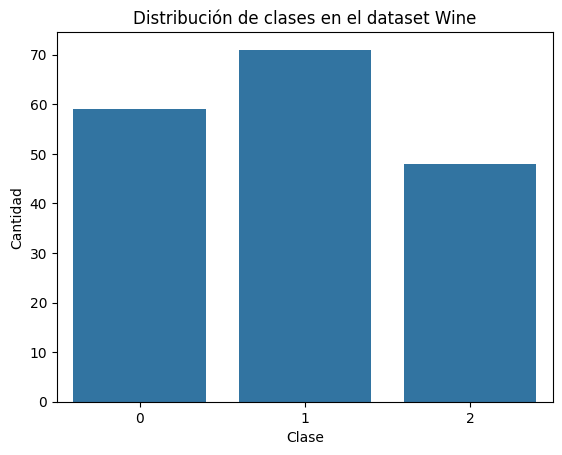


Estadísticas descriptivas:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453        

In [ ]:
from sklearn.datasets import load_wine
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

# Cargar el dataset
wine = load_wine()

# Convertir a DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

# Mostrar las primeras 15 filas del dataset
print("Primeras 15 filas del dataset:")
print(df.head(15))

# Muestra información general del dataset
print("\nInformación general del dataset:")
print(df.info())

# Mostrar los nombres de los campos del dataset
print("\nCampos del dataset:")
for i, nombre in enumerate(wine.feature_names):
    print(f"{i+1}. {nombre}")

# Crear tabla simple con los nombres de los campos
campos_df = pd.DataFrame({
    "Campo": wine.feature_names
})
print("\nTabla de campos del dataset:")
print(campos_df)

# Revisar balance de acuerdo al número de clases
print("\nDistribución de clases:")
print(df["target"].value_counts())

sns.countplot(x="target", data=df)
plt.title("Distribución de clases en el dataset Wine")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

# Estadísticas descriptivas de variables
print("\nEstadísticas descriptivas:")
print(df.describe())

# Mostrar las primeras 15 filas del dataset

# Muestra información general del dataset

# Genera una tabla con la descripción de cada campo y su significado

# Revisar balance deacuerdo al numero de clases

# Estadísticas descriptivas de variables

Preguntas:

¿Qué librerías se usan para el manejo de datos y visualización?

¿Qué librerías pertenecen a scikit-learn y para qué sirven?

¿Están balanceadas las clases?

¿Por qué eso es importante en clasificación?



**¿Qué librerías se usan para el manejo de datos y visualización?**
Las librerías utilizadas son pandas para el manejo de datos en forma de tablas, matplotlib para crear gráficos básicos y seaborn para generar visualizaciones más estilizadas y comparativas.

**¿Qué librerías pertenecen a scikit-learn y para qué sirven?**
Las librerías de scikit-learn usadas en este proyecto son:
- sklearn.datasets: permite cargar conjuntos de datos como el de vinos.
- sklearn.model_selection: sirve para dividir los datos en entrenamiento y prueba.
- sklearn.tree: se usa para crear y visualizar árboles de decisión.
- sklearn.metrics: permite evaluar el rendimiento del modelo con métricas como precisión y matriz de confusión.

**¿Están balanceadas las clases?**
Sí. Las tres clases del dataset están distribuidas de forma similar, lo que indica que el conjunto de datos está balanceado.

**¿Por qué eso es importante en clasificación?**
Porque si una clase tiene muchos más ejemplos que otra, el modelo puede aprender a favorecerla y cometer errores al predecir las clases menos representadas. Tener clases balanceadas mejora la precisión, la equidad y la capacidad del modelo para generalizar correctamente.



# 3. Visualización de datos

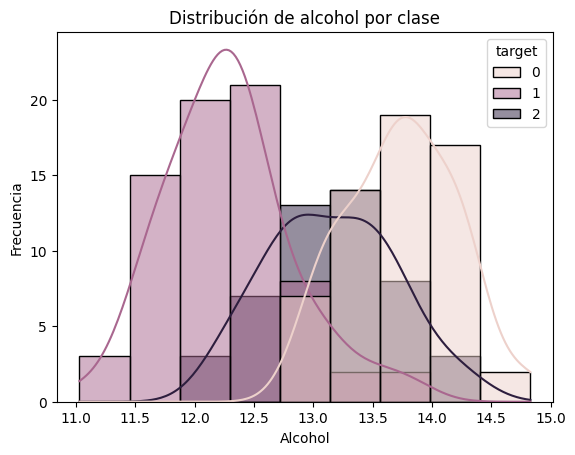

In [ ]:
# Visualizar distribuciones de algunas variables (alcohol)
sns.histplot(data=df, x="alcohol", hue="target", kde=True)
plt.title("Distribución de alcohol por clase")
plt.xlabel("Alcohol")
plt.ylabel("Frecuencia")
plt.show()
#La clase 0 tiende a tener vinos con mayor contenido de alcohol.
#La clase 1 se concentra en valores intermedios.
#La clase 2 tiene valores más bajos en comparación con la clase 0


¿Qué correlación existe entre la variable x y hue?

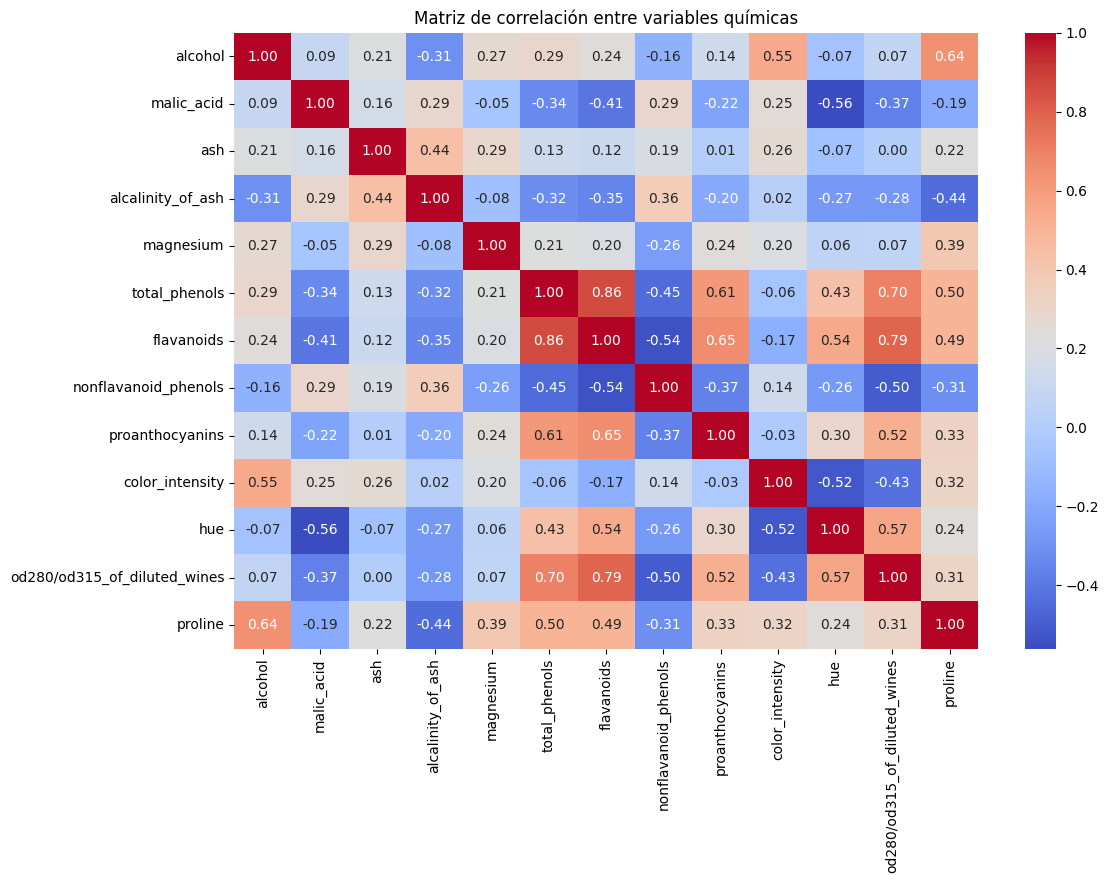

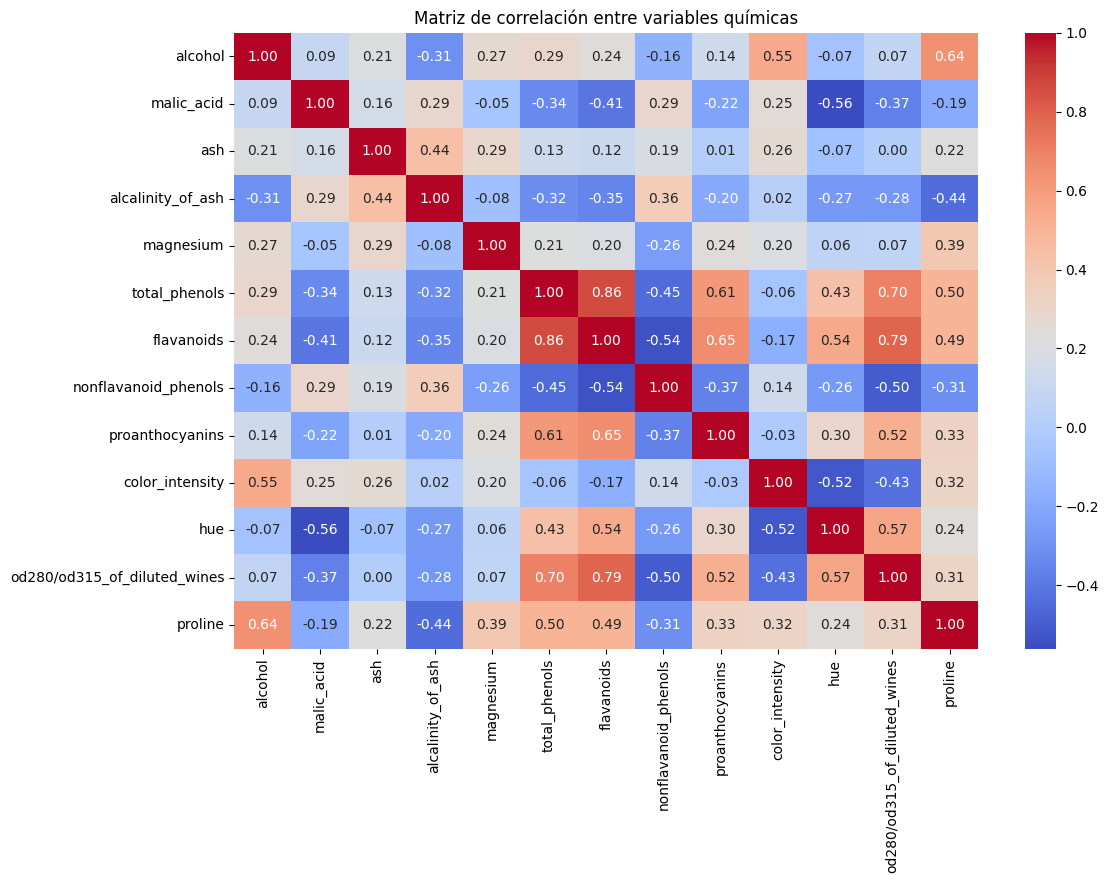

In [ ]:
# Visualizar matriz de correlación de variables
corr = df.drop("target", axis=1).corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", cbar=True)
plt.title("Matriz de correlación entre variables químicas")
plt.show()
# --- Análisis de la matriz de correlación entre variables químicas del vino ---

# Este gráfico muestra una matriz de correlación entre todas las variables numéricas del dataset,
# excluyendo la variable 'target', que representa la clase del vino.

# Cada celda representa el coeficiente de correlación entre dos variables, con valores entre -1 y 1.
# Un valor cercano a 1 indica una correlación positiva fuerte: ambas variables tienden a aumentar juntas.
# Un valor cercano a -1 indica una correlación negativa fuerte: cuando una variable aumenta, la otra disminuye.
# Un valor cercano a 0 indica poca o ninguna relación lineal entre las variables.

# El mapa de calor usa colores para facilitar la lectura:
# - Tonos cálidos (rojos) indican correlaciones positivas.
# - Tonos fríos (azules) indican correlaciones negativas.
# Además, se muestran los valores numéricos directamente en cada celda para mayor precisión.

# Este análisis permite identificar variables que están fuertemente relacionadas entre sí.
# Por ejemplo, 'flavanoids' tiene alta correlación con 'total_phenols' y 'od280/od315_of_diluted_wines',
# lo que sugiere que estas variables aportan información similar al modelo.

# También se observa una correlación negativa entre 'flavanoids' y 'nonflavanoid_phenols',
# lo que indica que cuando una está presente en mayor cantidad, la otra tiende a disminuir.

# Este tipo de gráfico es útil para seleccionar variables relevantes, evitar redundancias
# y mejorar el rendimiento de modelos de clasificación, como los árboles de decisión.

corr = df.drop("target", axis=1).corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", cbar=True)
plt.title("Matriz de correlación entre variables químicas")
plt.show()

¿Qué variables parecen más útiles para diferenciar clases?



#4. Segmentación 70% Entrenamiento, 15% Validación, 15% Prueba

In [ ]:
from sklearn.model_selection import train_test_split

# Separar variables predictoras y variable objetivo
X = df.drop("target", axis=1)  # 'target' es la variable de clase
y = df["target"]

# Dividir el 70% para entrenamiento y 30% para validación + prueba
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Dividir el 30% restante en 15% validación y 15% prueba
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Mostrar cuántas filas tiene cada conjunto
print(f"Filas en conjunto de entrenamiento: {X_train.shape[0]}")
print(f"Filas en conjunto de validación: {X_val.shape[0]}")
print(f"Filas en conjunto de prueba: {X_test.shape[0]}")

Filas en conjunto de entrenamiento: 124
Filas en conjunto de validación: 27
Filas en conjunto de prueba: 27


**¿Qué rol juega cada conjunto?**
El conjunto de entrenamiento sirve para que el modelo aprenda.
El de validación se usa para probar y ajustar el modelo mientras se entrena.
El de prueba se guarda para el final, para ver cómo se comporta con datos nuevos.

**¿Qué pasa si se evalúa primero en prueba y luego en validación?**
Se pierde la objetividad. El conjunto de prueba es para la evaluación final.
Si lo usas antes, ya no sirve para saber si el modelo realmente generaliza bien.
Primero se prueba en validación, se ajusta, y al final se evalúa en prueba



¿Qué rol juega cada conjunto (train, validation, test)?

¿Qué implicaciones tiene evaluar primero en prueba y después en validación?

# 5. Entrenamiento del modelo

In [ ]:
model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=0)
model.fit(X_train, y_train)

# Calcular Accuracy (porcentaje de aciertos)

#Visualizar modelo entrenado


DecisionTreeClassifier(max_depth=3, random_state=0)

¿Qué significa el parámetro criterion="gini"?

¿Qué pasaría si realizamos cambios al límite de max_depth?

¿Qué variable aparece en la raíz del árbol?

¿Por qué crees que esa variable fue elegida?

¿Cómo podrías interpretar las reglas del árbol?



**¿Qué significa el parámetro criterion="gini"?**
Es el criterio que usa el árbol para decidir cómo dividir los datos. Gini mide qué tan mezcladas están las clases en cada grupo. El árbol busca divisiones que generen grupos lo más puros posible.

**¿Qué pasaría si realizamos cambios al límite de max_depth?**
Si aumentas el valor, el árbol se vuelve más complejo y puede sobreajustarse. Si lo reduces, el árbol será más simple y general, pero podría perder precisión.

**¿Qué variable aparece en la raíz del árbol?**
La raíz muestra la variable que mejor separa las clases desde el inicio. En el dataset Iris, suele ser petal length cm

**¿Por qué crees que esa variable fue elegida?**
Porque es la que más ayuda a distinguir entre las clases. El árbol la selecciona automáticamente porque reduce más la impureza en la primera división.

**¿Cómo podrías interpretar las reglas del árbol?**
Cada rama representa una pregunta del tipo “¿la variable X es menor o mayor que un valor?”. Según la respuesta, el árbol sigue por una ruta distinta hasta llegar a una clase final. Es como un camino de decisiones paso a paso.


#6. Evaluación en validación

Accuracy en validación: 96.3 %


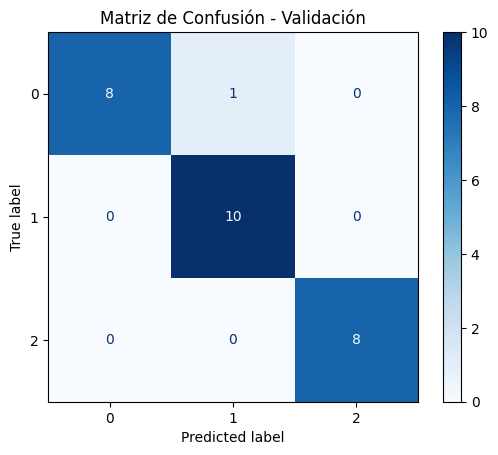

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 🎯 Evaluación del modelo con datos de validación
# ---------------------------------------------------------------

y_val_pred = model.predict(X_val)
# Genera las predicciones del modelo usando los datos de validación.

accuracy = accuracy_score(y_val, y_val_pred)
print("Accuracy en validación:", round(accuracy * 100, 2), "%")
# Calcula el porcentaje de aciertos del modelo sobre los datos de validación.

# ---------------------------------------------------------------
# 📊 Visualización de la matriz de confusión
# ---------------------------------------------------------------

cm = confusion_matrix(y_val, y_val_pred)
# Calcula la matriz de confusión comparando valores reales vs predichos.

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Validación")
plt.show()
# Muestra la matriz de confusión con colores y etiquetas.

¿Qué relación tiene la metrica de accuracy en la fase de entrenamiento y validación con el riesgo de overfitting?

¿Cómo interpreta los resultados en la fase de validación en relación con la matriz de confusión?

**¿Qué relación tiene la métrica de accuracy en la fase de entrenamiento y validación con el riesgo de overfitting?**
Si el accuracy en entrenamiento es muy alto y en validación es mucho más bajo, el modelo probablemente está sobreajustado. Eso significa que aprendió demasiado los datos de entrenamiento y no generaliza bien a nuevos datos.

**¿Cómo interpreta los resultados en la fase de validación en relación con la matriz de confusión?**
La matriz de confusión muestra en qué clases el modelo acierta y en cuáles se equivoca. Si hay muchos errores en ciertas clases, puede indicar que el modelo no las distingue bien. Es útil para ver si el modelo tiene sesgo hacia alguna clase o si confunde dos clases entre sí.


#7. Evaluación en prueba

Accuracy en prueba: 100.0 %


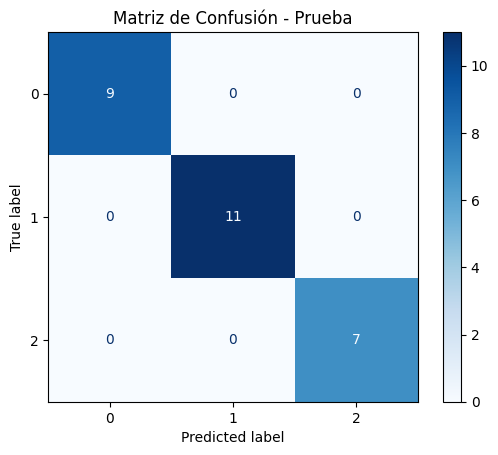

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 🎯 Evaluación del modelo con datos de prueba
# ---------------------------------------------------------------

y_test_pred = model.predict(X_test)
# Genera las predicciones del modelo usando los datos de prueba.

accuracy = accuracy_score(y_test, y_test_pred)
print("Accuracy en prueba:", round(accuracy * 100, 2), "%")
# Calcula el porcentaje de aciertos del modelo sobre los datos de prueba.

# ---------------------------------------------------------------
# 📊 Visualización de la matriz de confusión
# ---------------------------------------------------------------

cm = confusion_matrix(y_test, y_test_pred)
# Calcula la matriz de confusión comparando valores reales vs predichos.

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Prueba")
plt.show()
# Muestra la matriz de confusión con colores y etiquetas.


¿Qué información adicional da la matriz de confusión frente al accuracy?

¿Qué se puede concluir del modelo en esta sección?

**¿Qué información adicional da la matriz de confusión frente al accuracy?**
La matriz de confusión muestra en detalle cuántas predicciones fueron correctas por clase y cuántas fueron errores. Permite ver si el modelo confunde ciertas clases entre sí, algo que el accuracy no revela. Es útil para entender el tipo de errores que comete el modelo.

**¿Qué se puede concluir del modelo en esta sección?**
Se puede evaluar qué tan bien generaliza el modelo con datos nuevos. Si el accuracy es alto y la matriz muestra pocos errores, el modelo está funcionando bien. Si hay muchas confusiones entre clases, puede necesitar ajustes o más datos para mejorar.


#8. Reto

Realiza mejoras para aumentar la metrica de accuracy, genera los cambios que crea coveniente.